# PHOENIX full-spectrum classification example

This notebook demonstrates a generic PHOENIX-based full-spectrum fitting workflow in Spyctres using a reduced X-SHOOTER UVB spectrum of Gaia21ccu.

The same pattern can be adapted to other reduced 1D spectra once the appropriate reader and fitting windows are chosen.

In [1]:
from pathlib import Path
import sys
import warnings

# Prefer the local repository checkout when the notebook is run from inside the repo.
repo_root = None
for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (candidate / "Spyctres").exists() and (candidate / "setup.py").exists():
        repo_root = candidate
        break

if repo_root is not None and str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

# Keep notebook output tidy.
warnings.filterwarnings(
    "ignore",
    message=r"pkg_resources is deprecated as an API.*",
    category=UserWarning,
    module=r"pysynphot.*",
)

import numpy as np
import matplotlib.pyplot as plt
import Spyctres

from Spyctres.config import load_user_config, get_config_value, resolve_setting
from Spyctres.io import read_spectrum, make_padded_window_segments
from Spyctres.phoenix import PhoenixLibrary
from Spyctres.waveutils import convert_wavelength_medium
from Spyctres.fitting import (
    fit_phoenix_full_spectrum,
    build_effective_fit_mask,
    reconstruct_phoenix_legendre_models_for_segments,
)
from Spyctres.plotting import plot_full_spectrum_fit, plot_binned_spectra
from Spyctres.Spyctres import load_telluric_lines

print("Using Spyctres from:")
print(Spyctres.__file__)

Using Spyctres from:
/home/Tux/ytsapras/Installed_Programs/Spyctres-dev/Spyctres/__init__.py


In [4]:
# Demo input file. Replace this with your own reduced 1D spectrum if needed.
spectrum_path = Path("/home/Tux/ytsapras/Installed_Programs/Spyctres-dev/examples/data/TOO_Gaia21ccu_SCI_SLIT_FLUX_MERGE1D_UVB.fits")

config = load_user_config()
phoenix_dir_cfg = get_config_value(config, "paths", "phoenix_dir", default=None)

phoenix_dir = resolve_setting(
    cli_value=None,
    env_var_name="SPYCTRES_PHOENIX_DIR",
    config_value=phoenix_dir_cfg,
    default=None,
)

if phoenix_dir is None:
    raise RuntimeError(
        "No PHOENIX directory found. Set SPYCTRES_PHOENIX_DIR or "
        "[paths].phoenix_dir in ~/.config/spyctres/config.toml."
    )

phoenix_dir = str(phoenix_dir)

print("Spectrum path:", spectrum_path)
print("PHOENIX dir :", phoenix_dir)

Spectrum path: /home/Tux/ytsapras/Installed_Programs/Spyctres-dev/examples/data/TOO_Gaia21ccu_SCI_SLIT_FLUX_MERGE1D_UVB.fits
PHOENIX dir : /home/Tux/ytsapras/Installed_Programs/astroARIADNE/Models_Dir/PHOENIXv2


In [5]:
# Read the X-SHOOTER spectrum and print the key metadata
seg0 = read_spectrum(str(spectrum_path), instrument="xshooter")

arm = str(seg0.meta.get("arm", "")).strip().upper()
if arm and arm != "UVB":
    raise ValueError(
        f"This example notebook expects the X-SHOOTER UVB reference dataset, "
        f"but the reader returned arm={arm!r}."
    )
print("Name         :", seg0.name)
print("Object       :", seg0.meta.get("object"))
print("Instrument   :", seg0.meta.get("instrument"))
print("Arm          :", seg0.meta.get("arm"))
print("Wave medium  :", seg0.wave_medium)
print("Wave frame   :", seg0.wave_frame)
print("R metadata   :", seg0.meta.get("resolution_R"))
print("Barycorr [km/s]:", seg0.meta.get("barycorr_kms"))
print("Pixels       :", len(seg0.wave))
print("Wave range [A]:", float(np.min(seg0.wave)), float(np.max(seg0.wave)))

Name         : TOO_Gaia21ccu_SCI_SLIT_FLUX_MERGE1D_UVB.fits
Object       : Gaia21ccu
Instrument   : XSHOOTER
Arm          : UVB
Wave medium  : air
Wave frame   : topocentric
R metadata   : 5400.0
Barycorr [km/s]: 13.5272193938759
Pixels       : 12854
Wave range [A]: 2989.2000000000003 5559.8


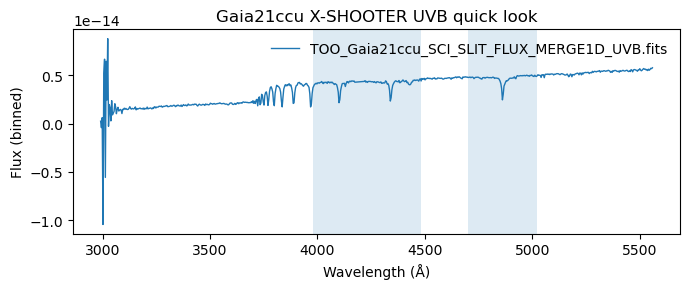

In [6]:
# Quick-look overview using the built-in plotting helper which replaces the raw spectrum with median-binned flux
# `highlight_regions` visually marks the three Balmer fit windows
fig, ax = plot_binned_spectra(
    spectra=[seg0],
    nbins=700,
    title="Gaia21ccu X-SHOOTER UVB quick look",
    highlight_regions=[(3980.0, 4220.0), (4220.0, 4480.0), (4700.0, 5020.0)],
)
plt.show()

# Uncomment to plot all raw data without using the built-in plotter
#plt.figure(figsize=(11, 4))
#plt.plot(seg0.wave, seg0.flux, lw=0.7)
#plt.xlabel("Wavelength (Å)")
#plt.ylabel("Flux")
#plt.title("Gaia21ccu X-SHOOTER UVB quick look")
#plt.tight_layout()
#plt.show()

## Next step: Restrict the spectrum to the fitting range

The full X-SHOOTER UVB spectrum covers a broader wavelength range than we want to use for this example.

Here we focus on the Balmer-line region and split it into three padded fitting segments:

- Hδ: 3980–4220 Å
- Hγ: 4220–4480 Å
- Hβ: 4700–5020 Å

Each fitting window is given a small wavelength padding of 5 Å. The padded support is used for forward-model evaluation, while the inner window is the part that contributes to the fit statistic.

In [7]:
# Validated X-SHOOTER UVB benchmark wavelength span and notebook-style Balmer windows.
wmin = 3980.0
wmax = 5500.0
window_pad = 5.0

balmer_windows = [
    ("Hδ", 3980.0, 4220.0),
    ("Hγ", 4220.0, 4480.0),
    ("Hβ", 4700.0, 5020.0),
]

# Clip the full UVB segment to the benchmark fitting span.
seg_clip = seg0.window(
    wmin=wmin,
    wmax=wmax,
    clip_left=0,
    clip_right=0,
    name_suffix="fitwin",
)

# Build one padded SpectrumSegment per Balmer window.
segments = make_padded_window_segments(
    seg_clip,
    [(label, w0, w1) for label, w0, w1 in balmer_windows],
    pad=window_pad,
)

print("Clipped segment:")
print("  name       :", seg_clip.name)
print("  pixels      :", len(seg_clip.wave))
print("  wave range  :", float(np.min(seg_clip.wave)), float(np.max(seg_clip.wave)))

print("\nBalmer window segments:")
for s in segments:
    print(
        f"  {s.name:>2s} : "
        f"pixels={len(s.wave):4d}   "
        f"support=[{float(np.min(s.wave)):.1f}, {float(np.max(s.wave)):.1f}] Å   "
        f"fit_pixels={int(np.sum(s.mask))}"
    )

Clipped segment:
  name       : TOO_Gaia21ccu_SCI_SLIT_FLUX_MERGE1D_UVB.fits_fitwin
  pixels      : 7601
  wave range  : 3980.0 5500.0

Balmer window segments:
  Hδ : pixels=1226   support=[3980.0, 4225.0] Å   fit_pixels=974
  Hγ : pixels=1351   support=[4215.0, 4485.0] Å   fit_pixels=1298
  Hβ : pixels=1651   support=[4695.0, 5025.0] Å   fit_pixels=1585


## Next step: Define which pixels should be excluded from the fit

Even within the Balmer windows, we usually do not want to fit every pixel.

For the validated X-SHOOTER benchmark, the broad Balmer wings are fitted, but the central line cores are excluded with a symmetric core mask.

Why do this? In many stellar-atmosphere applications, the Balmer wings are the cleaner part of the profile for constraining parameters such as effective temperature and surface gravity, while the very central cores can be more sensitive to effects that are not the main target of this simple example.

How should you choose the mask? There is no single universal value. The mask width should be treated as a modelling choice and checked against the data and the scientific goal. In this example, a core half-width of 12 Å was adopted.

In practice:

- use a wider core mask if the line centers are visibly mismatched, contaminated, or dominated by structure you do not want to model
- use a narrower mask if you have a reason to trust and fit the central cores as part of your science case
- always inspect the final fit visually and, if needed, test a few sensible mask widths rather than assuming one value is always correct

In [8]:
# Benchmark choice: exclude +/- 12 A around the Balmer line centers.
core_mask_halfwidth = 6.0
balmer_centers_vac = np.array([4101.74, 4340.47, 4861.33], dtype=float)

# Convert the Balmer centers into the same wavelength medium as the data.
wave_medium = str(segments[0].wave_medium).lower()
if wave_medium in ("air", "vacuum"):
    balmer_centers = convert_wavelength_medium(
        balmer_centers_vac,
        from_medium="vacuum",
        to_medium=wave_medium,
    )
else:
    balmer_centers = balmer_centers_vac.copy()

# Return True for pixels that should be excluded from the fit.
def exclude_mask(wave):
    wave = np.asarray(wave, dtype=float)
    m = np.zeros_like(wave, dtype=bool)
    for c in balmer_centers:
        m |= np.abs(wave - c) <= core_mask_halfwidth
    return m

# Build the actual fit masks used in each Balmer window.
used_masks_plot = [
    build_effective_fit_mask(seg, exclude_mask=exclude_mask)
    for seg in segments
]

print("Per-window used pixels:")
for seg_i, mask_i in zip(segments, used_masks_plot):
    print(f"  {seg_i.name}: {int(np.sum(mask_i))} / {len(seg_i.wave)}")

print("\nTotal used pixels:", int(sum(np.sum(m) for m in used_masks_plot)))

Per-window used pixels:
  Hδ: 916 / 1226
  Hγ: 1238 / 1351
  Hβ: 1525 / 1651

Total used pixels: 3679


## Next step: Define the PHOENIX fitting grid

The PHOENIX template library contains a large model grid in effective temperature, metallicity, and surface gravity.

For this notebook, we do not use the full installed grid. Instead, we restrict the fit to a smaller subgrid around the part of parameter space relevant to the validated X-SHOOTER Balmer-wing solution. This keeps the example faster and makes the fit easier to interpret.

In [10]:
# Build the PHOENIX library interface from the local template directory.
phoenix_lib = PhoenixLibrary(phoenix_dir, verbose=True)

# Inspect the actually installed PHOENIX axes on disk.
teff_avail, feh_avail, logg_avail = phoenix_lib.available_axes()

print("Installed Teff range:", float(np.min(teff_avail)), float(np.max(teff_avail)))
print("Installed [Fe/H] range:", float(np.min(feh_avail)), float(np.max(feh_avail)))
print("Installed logg range:", float(np.min(logg_avail)), float(np.max(logg_avail)))

# Benchmark subgrid:
# These ranges match the Balmer-only X-SHOOTER smoke-test defaults used for the
# validated notebook-style workflow.
#
# Teff  :  9000 to 11600 K
# [Fe/H]: -2.0 to  0.0
# logg  :  2.0 to  4.5
teff_grid_req = teff_avail[(teff_avail >= 9000.0) & (teff_avail <= 11600.0)]
feh_grid_req  = feh_avail[(feh_avail  >= -2.0)   & (feh_avail  <= 0.0)]
logg_grid_req = logg_avail[(logg_avail >= 2.0)   & (logg_avail <= 4.5)]

# Trim to a complete rectangular subgrid that actually exists on disk.
teff_grid_fit, feh_grid_fit, logg_grid_fit = phoenix_lib.complete_subgrid(
    teff_grid_req,
    feh_grid_req,
    logg_grid_req,
)

print("\nRequested benchmark subgrid:")
print("Teff :", teff_grid_req)
print("FeH  :", feh_grid_req)
print("logg :", logg_grid_req)

print("\nComplete subgrid used for fitting:")
print("Teff :", teff_grid_fit)
print("FeH  :", feh_grid_fit)
print("logg :", logg_grid_fit)

Installed Teff range: 2300.0 12000.0
Installed [Fe/H] range: -4.0 1.0
Installed logg range: 0.0 6.0

Requested benchmark subgrid:
Teff : [ 9000.  9200.  9400.  9600.  9800. 10000. 10200. 10400. 10600. 10800.
 11000. 11200. 11400. 11600.]
FeH  : [-2.  -1.5 -1.  -0.5 -0. ]
logg : [2.  2.5 3.  3.5 4.  4.5]

Complete subgrid used for fitting:
Teff : [ 9000.  9200.  9400.  9600.  9800. 10000. 10200. 10400. 10600. 10800.
 11000. 11200. 11400. 11600.]
FeH  : [-2.  -1.5 -1.  -0.5 -0. ]
logg : [2.  2.5 3.  3.5 4.  4.5]


## Next step: Run the PHOENIX fit

We now fit the three Balmer-window segments with the generic PHOENIX full-spectrum fitter.

The nonlinear fit parameters are:

- effective temperature `Teff`
- metallicity `[Fe/H]`
- surface gravity `logg`
- radial velocity `RV`

The fitter also needs a few modelling choices, such as:

- which PHOENIX subgrid to use
- whether to exclude some pixels from the fit
- which forward-model path to use
- what instrumental resolving power to assume
- what continuum polynomial degree to use

In this notebook, we keep those choices simple and close to the reference X-SHOOTER setup.

To inspect the full function interface, you can run:

```python
help(fit_phoenix_full_spectrum)

In [11]:
# Use the resolving power inferred by the X-SHOOTER reader.
# This lets the forward model include instrumental broadening.
R = seg0.meta.get("resolution_R", None)

# Keep it simple. We do not apply an extra barycentric term here, even though the reader
# reports one in the metadata. That can be explored later if needed.
rv_bary_kms = 0.0

# Initial guess chosen to be close to the validated X-SHOOTER reference family.
# (Teff, [Fe/H], logg, RV)
p0 = (9800.0, -0.5, 3.0, -5.0)

print("R used:", R)
print("rv_bary_kms used:", rv_bary_kms)
print("Initial guess p0:", p0)

# Now comes the main fitter call-->
#
# The most important arguments to note here are:
# - segments:
#   the list of SpectrumSegment objects we want to fit
# - phoenix_lib:
#   the local PHOENIX template library interface
# - p0:
#   the initial guess for (Teff, [Fe/H], logg, RV)
# - exclude_mask:
#   the callable that marks pixels to exclude from the fit
# - mdeg:
#   the degree of the multiplicative Legendre continuum polynomial
# - R:
#   the assumed resolving power for instrumental broadening
# - forward_model="native_interp":
#   use the wavelength-space forward-model order validated for X-SHOOTER
# - teff_grid / feh_grid / logg_grid:
#   the PHOENIX subgrid we allow the fit to explore
# - rv_init="grid":
#   do a coarse RV scan first to help the optimizer start near the right velocity
result = fit_phoenix_full_spectrum(
    segments=segments,
    phoenix_lib=phoenix_lib,
    p0=p0,
    exclude_mask=exclude_mask,
    mdeg=2,
    rv_bary_kms=rv_bary_kms,
    R=R,
    forward_model="native_interp",
    model_margin_A=200.0,
    teff_grid=teff_grid_fit,
    feh_grid=feh_grid_fit,
    logg_grid=logg_grid_fit,
    cache_path="/tmp/spyctres_example_xshooter_cache.npz",
    rv_init="grid",
    rv_grid_n=81,
    verbose=1,
    max_nfev=300,
)

print("\nFit result summary:")
for key in ["teff", "feh", "logg", "rv_kms", "chi2", "dof", "chi2_red", "success", "message"]:
    print(f"{key:>8s} : {result[key]}")

R used: 5400.0
rv_bary_kms used: 0.0
Initial guess p0: (9800.0, -0.5, 3.0, -5.0)
Loaded PHOENIX cache from /tmp/spyctres_example_xshooter_cache.npz
RV init grid best: -22.5
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         1.4369e+04                                    1.79e+04    
       1              2         1.1196e+04      3.17e+03       3.46e+02       4.61e+03    
       2              3         1.0756e+04      4.40e+02       9.00e+01       2.02e+03    
       3              4         1.0727e+04      2.85e+01       1.50e+01       1.38e+03    
       4              5         1.0722e+04      5.13e+00       5.02e+01       8.37e+02    
       5              6         1.0719e+04      3.59e+00       9.39e+01       5.89e+02    
       6              8         1.0715e+04      3.38e+00       4.02e+01       2.10e+03    
       7             10         1.0715e+04      4.47e-01       9.83e+00       2.01e+03    
       8

## If this fit ran end to end, great! This is the main milestone for this example.

## Next step: Inspect the fitted model

Now that the fit has finished, we reconstruct the PHOENIX model on each Balmer-window segment and compare it directly to the data.

This is the main diagnostic step. If the fit is unsatisfactory, the plots will usually show whether the main issue is the continuum treatment, the masking, the fit windows, the assumed broadening, or the chosen parameter subgrid.

Spyctres already provides `reconstruct_phoenix_legendre_models_for_segments()` to rebuild the fitted model on each segment grid and `plot_full_spectrum_fit()` to display data, model, used pixels, and excluded regions.

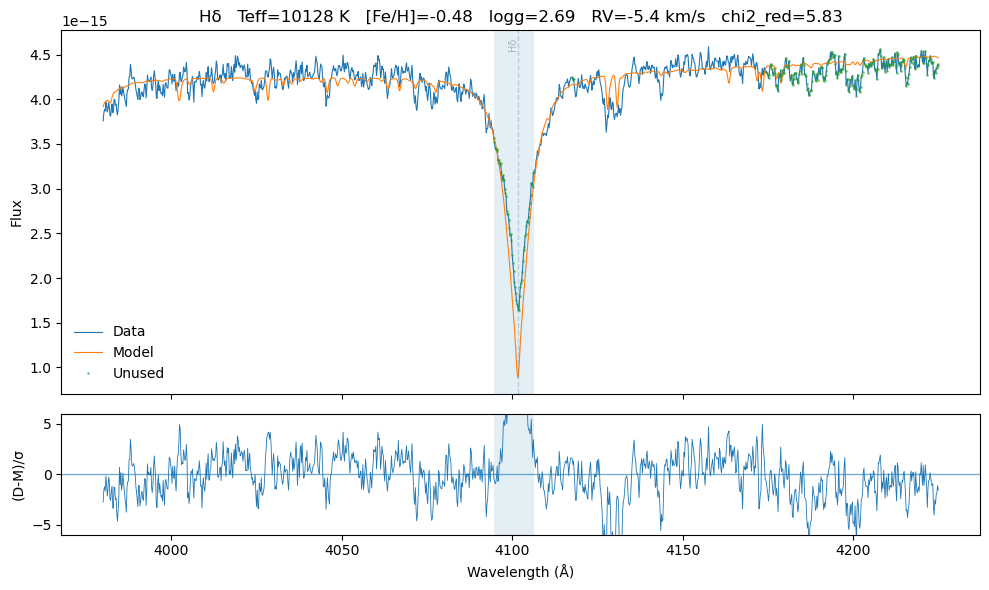

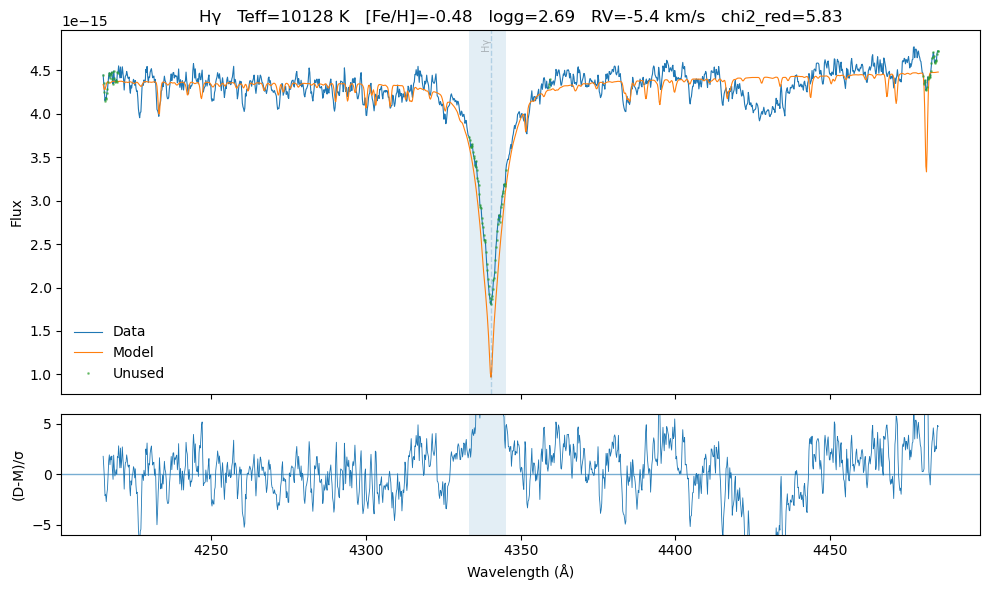

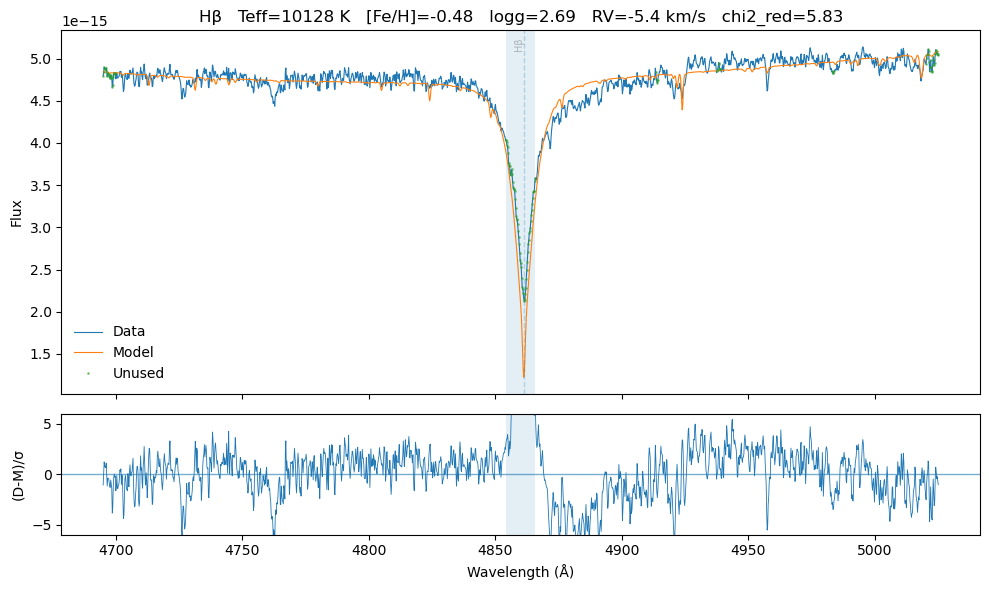

In [12]:
# Reconstruct the fitted PHOENIX model on the full wavelength grid of each segment.
#
# The fitter solved for the physical parameters and the per-segment continuum terms.
# Here we just rebuild the final model arrays so we can inspect the fit visually.
model_list, coeffs_list, used_masks, excluded_masks = reconstruct_phoenix_legendre_models_for_segments(
    segments=segments,
    phoenix_lib=phoenix_lib,
    fit_result=result,
    exclude_mask=exclude_mask,
    mdeg=2,
    rv_bary_kms=rv_bary_kms,
    R=R,
    fwhm_kms=None,
    forward_model="native_interp",
    model_margin_A=200.0,
)

# Plot one panel per Balmer window using the built-in full-spectrum fit plotter.
# Then manually expand the y-range of the top panel so the masked line cores
# remain visible instead of being cropped too tightly.
for seg_i, model_i, used_i, excl_i in zip(segments, model_list, used_masks, excluded_masks):
    title = (
        f"{seg_i.name}   "
        f"Teff={result['teff']:.0f} K   "
        f"[Fe/H]={result['feh']:.2f}   "
        f"logg={result['logg']:.2f}   "
        f"RV={result['rv_kms']:.1f} km/s   "
        f"chi2_red={result['chi2_red']:.2f}"
    )

    fig, axes = plot_full_spectrum_fit(
        wave=seg_i.wave,
        flux=seg_i.flux,
        err=seg_i.err,
        model=model_i,
        used_mask=used_i,
        excluded_mask=excl_i,
        title=title,
        line_groups=["balmer"],
    )

    # axes[0] is the top data/model panel, axes[1] is the residual panel.
    ax_top = axes[0]
    
    # Use the full flux and model ranges so the bottoms of the Balmer lines
    # are visible even if those pixels are masked from the fit.
    y_min = min(np.nanmin(seg_i.flux), np.nanmin(model_i))
    y_max = max(np.nanmax(seg_i.flux), np.nanmax(model_i))
    y_pad = 0.05 * (y_max - y_min)

    ax_top.set_ylim(y_min - y_pad, y_max + y_pad)

    plt.show()

In [13]:
fit_summary = {
    "Teff [K]": result["teff"],
    "[Fe/H]": result["feh"],
    "logg": result["logg"],
    "RV [km/s]": result["rv_kms"],
    "Reduced chi^2": result["chi2_red"],
}

print("Generic PHOENIX fit summary:")
for key, value in fit_summary.items():
    if isinstance(value, (int, float, np.floating)):
        print(f"  {key:>15s} : {value:.3f}")
    else:
        print(f"  {key:>15s} : {value}")

print("\nInterpretation:")
print(
    f"The spectrum is best matched by a model with Teff ≈ {result['teff']:.0f} K, "
    f"[Fe/H] ≈ {result['feh']:.2f}, logg ≈ {result['logg']:.2f}, "
    f"and RV ≈ {result['rv_kms']:.1f} km/s."
)
print(
    "This should be read as a first PHOENIX-based classification from the generic workflow, "
    "not as a final precision measurement."
)

Generic PHOENIX fit summary:
         Teff [K] : 10127.994
           [Fe/H] : -0.479
             logg : 2.694
        RV [km/s] : -5.362
    Reduced chi^2 : 5.831

Interpretation:
The spectrum is best matched by a model with Teff ≈ 10128 K, [Fe/H] ≈ -0.48, logg ≈ 2.69, and RV ≈ -5.4 km/s.
This should be read as a first PHOENIX-based classification from the generic workflow, not as a final precision measurement.


## Interpretation of the result

These values should be treated as a first broad model-based classification, not as a final high-precision stellar analysis. The residuals still show some structure, which means the fit is not perfect and the exact parameter values can depend on modelling choices such as the continuum treatment, the wavelength windows, and the masking strategy.

The fitting can be improved by testing modelling choices systematically.

Some practical things to try in your own reductions are:

- revise the fitted wavelength windows
- revise the Balmer-core mask width
- test different assumed resolving powers
- verify wavelength medium and barycentric handling
- compare different PHOENIX subgrids
- use several starting points
- inspect each fitted line separately
- try more local continuum strategies when broad lines dominate the fit

Spyctres also includes higher-level ideas in `Spyctres.recipes`. That module contains examples of more specialized workflows, including helpers for Balmer-line metadata, local sideband normalization, line-core masking, and plotting. We did not use those tools for this first generic fit, but they are useful places to look if you want to refine the analysis.

For many real spectra, fitting is iterative: inspect the residuals, revise the modelling choices, and fit again.

This is the end of this tutorial.